#### <span style="color:cyan">**Imports**</span>

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from util.data_preprocessing import *
from util.pca_plotting import *
from util.classes.PCADataset import *
from util.classes.PcaMLP import *
from util.model_eval import *
from util.model_optimization import *

from preprocessing.pipelines import build_pca_pipeline
import json
import os
import math
import numpy as np
import torch

#### <span style="color:cyan">**Data Preprocessing**</span>

BLW/TLW >= 1.5: kept 1493/1947 samples
Feature table (abs):
       pc_0      pc_1      pc_2      pc_3      pc_4  ...     pc_20     pc_21  \
0  0.787981  3.826156 -3.593585 -2.038977  1.369221  ... -0.108888 -0.007785   
1 -1.718868  4.160776 -0.516656 -1.041473 -1.380097  ...  0.023132 -0.104381   
2  3.155178 -3.118782  0.417798  1.952882 -1.727219  ...  0.055328  0.125416   
3 -5.116368 -6.234717 -3.260441 -3.056086  1.494856  ...  0.013555  0.078538   
4 -3.258564  0.334024 -0.010285  3.670578 -2.151730  ... -0.019450 -0.332629   

      pc_22     pc_23     pc_24  
0  0.096832  0.014011 -0.007352  
1  0.036525 -0.016234  0.014047  
2  0.089610  0.023005  0.121322  
3 -0.155917 -0.168034  0.143981  
4  0.159638 -0.177604  0.084514  

[5 rows x 25 columns]



c:\Users\robert\Code\capstone\capstone_SiC_gratings\ML_project\util\pca_plotting.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


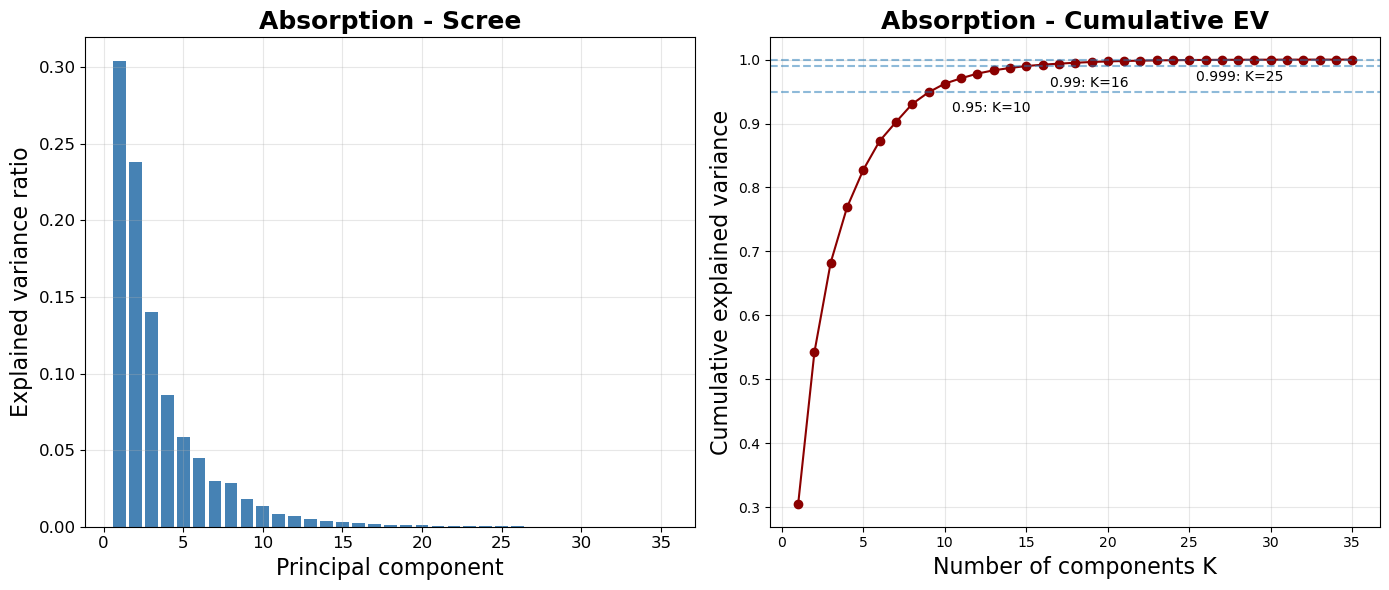

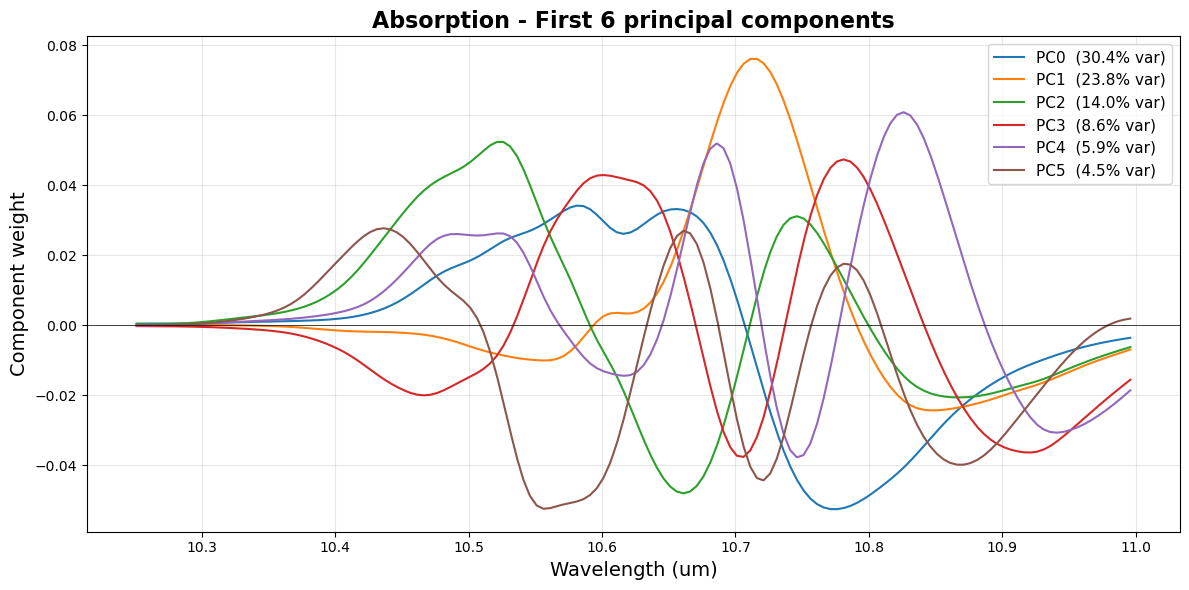

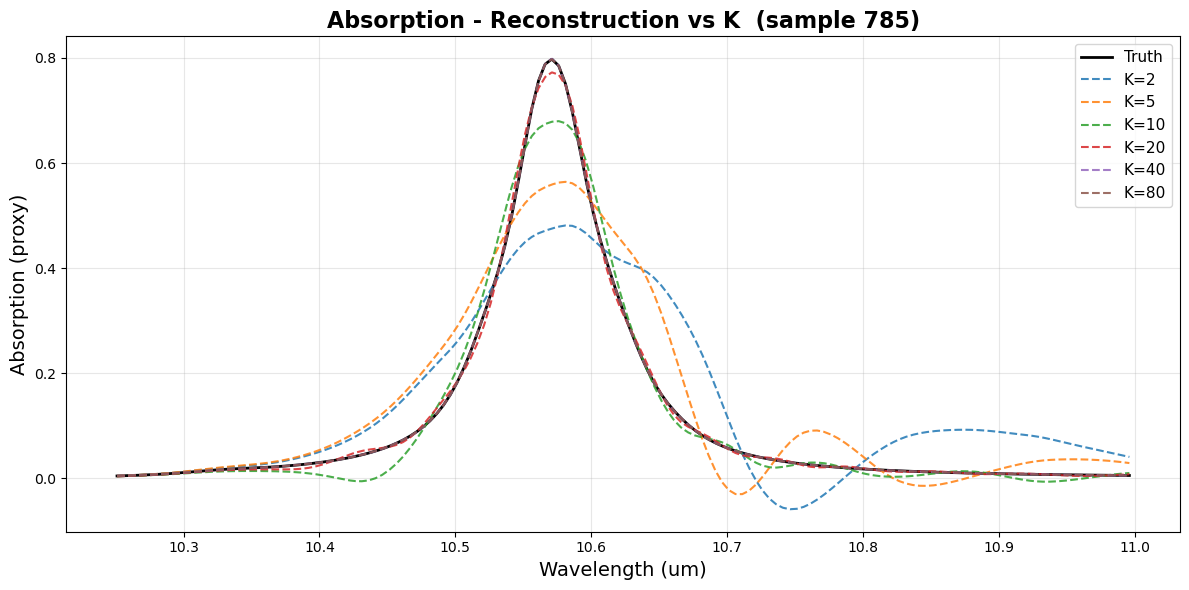

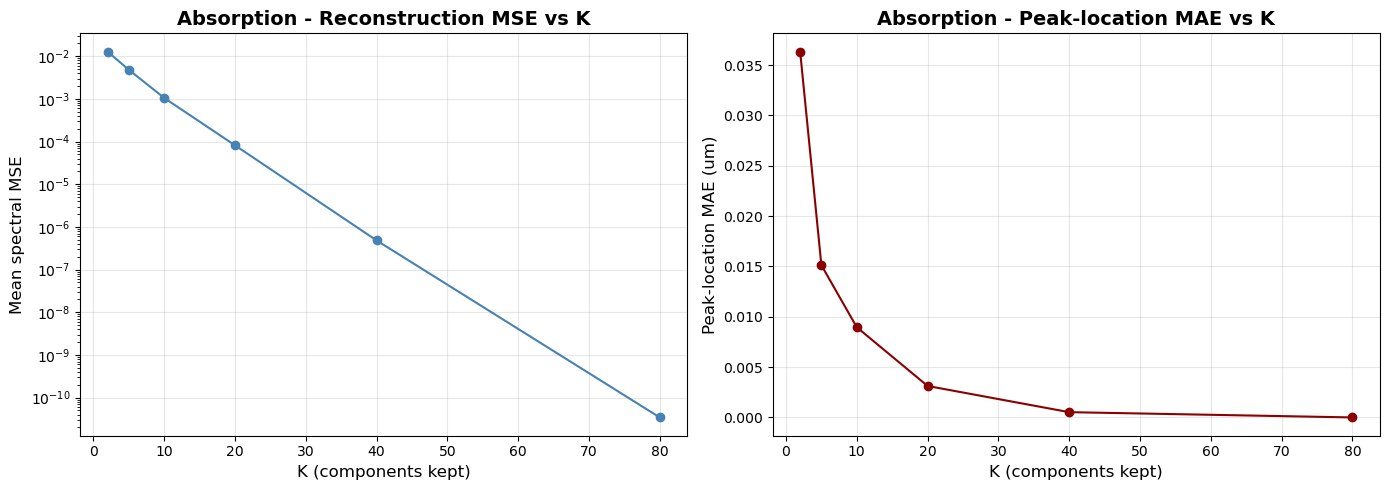

Absorption K-sweep:
  K=  2  MSE=1.279e-02  peak-MAE=0.0363 um
  K=  5  MSE=4.818e-03  peak-MAE=0.0151 um
  K= 10  MSE=1.052e-03  peak-MAE=0.0090 um
  K= 20  MSE=8.169e-05  peak-MAE=0.0031 um
  K= 40  MSE=4.825e-07  peak-MAE=0.0005 um
  K= 80  MSE=3.440e-11  peak-MAE=0.0000 um


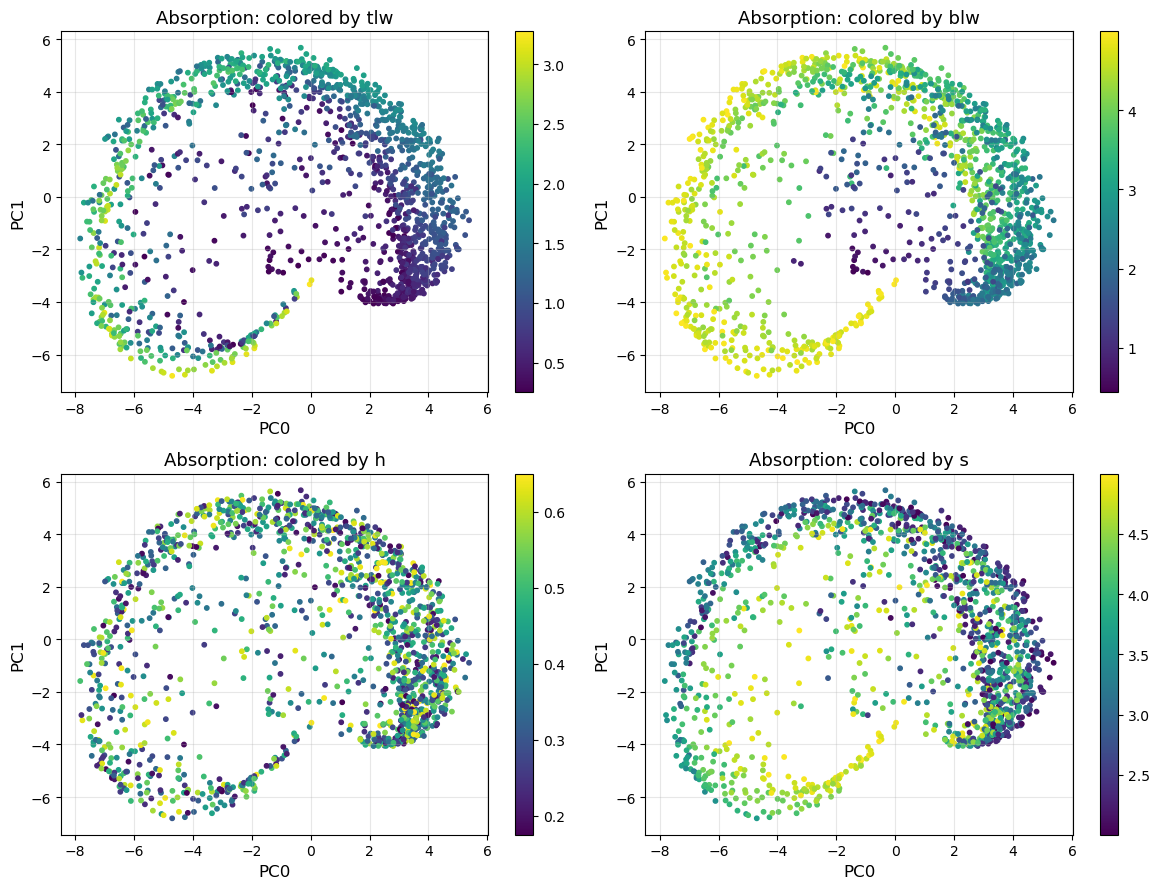

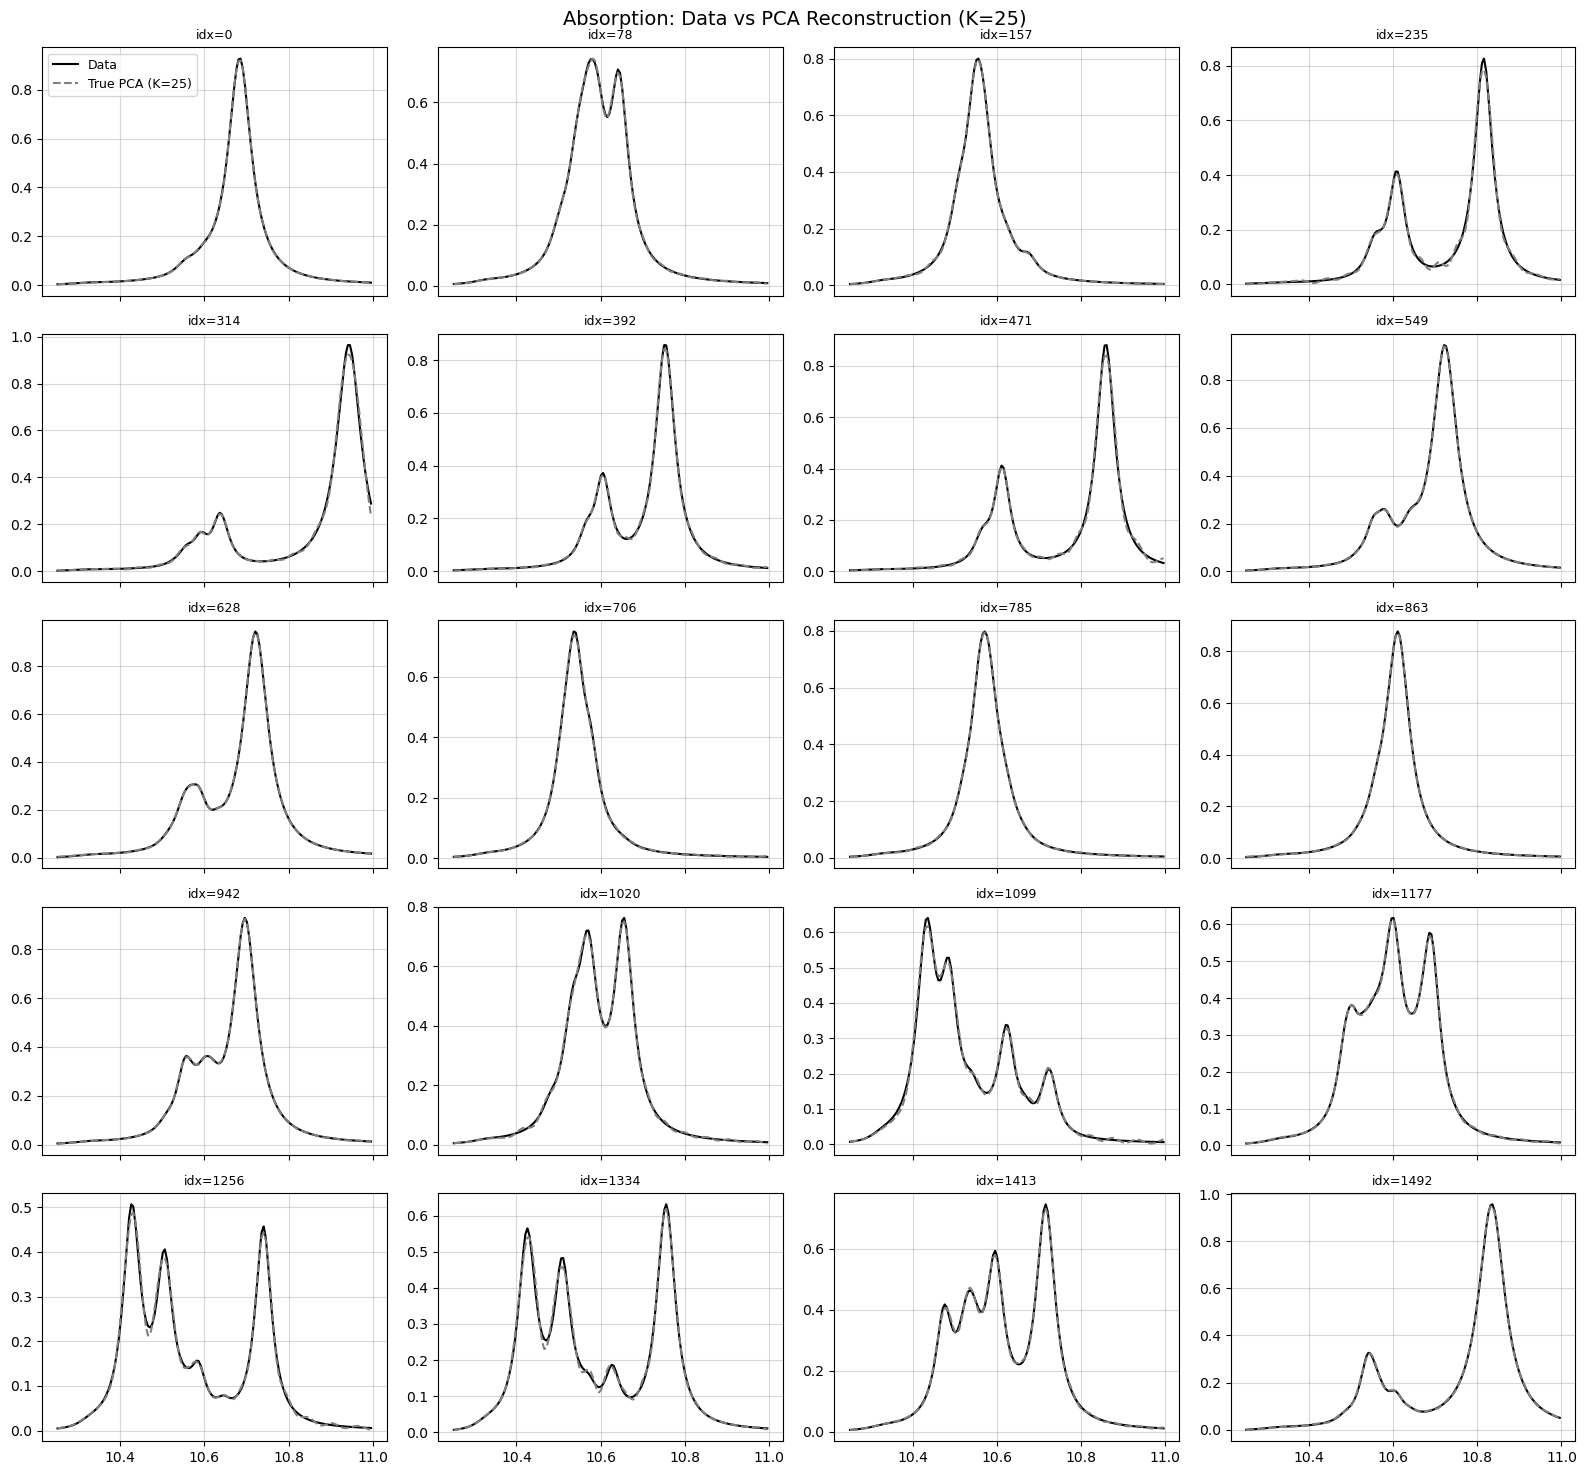

In [2]:
#### DATA PREPROCESSING PIPELINE - PCA FEATURES (4D GEOMETRY) ####
# Config
pd.set_option('display.max_columns', 10)
DATA_PATH = '../data/batch2'
DOMAIN = (10.25, 11.0)
INTERP = 10
TEST_IDX = np.arange(0, 1947, 100)
K = 25
K_SWEEP = [2, 5, 10, 20, 40, 80]
N_PC_SHOW = 6

# Filter out samples with BLW/TLW below this value (set to 0 to disable filtering)
MIN_BLW_TLW_RATIO = 1.5

# Import Data
geom_labels, geom_table, refl_data, abs_data, refl_bg, abs_bg, wl = import_data(DATA_PATH)

# Filter samples by BLW/TLW ratio
if MIN_BLW_TLW_RATIO > 0:
    ratio = geom_table['blw'] / geom_table['tlw']
    keep_mask = ratio >= MIN_BLW_TLW_RATIO
    n_before = len(geom_table)
    geom_table = geom_table.loc[keep_mask].reset_index(drop=True)
    refl_data  = refl_data.loc[keep_mask].reset_index(drop=True)
    abs_data   = abs_data.loc[keep_mask].reset_index(drop=True)
    print(f'BLW/TLW >= {MIN_BLW_TLW_RATIO}: kept {len(geom_table)}/{n_before} samples')
    # Re-space TEST_IDX evenly across the filtered sample space (same count as before)
    TEST_IDX = np.linspace(0, len(geom_table) - 1, len(TEST_IDX)).astype(int)

# Print Data and geometry Table for inspection
# print(f'\ngeometry labels (4D):\n{geom_labels}\n')
# print(f'geometry_table (4D):\n{geom_table.head()}\n')
# print(f'absorption data:\n{abs_data.head()}\n')
# print(f'absorption background:\n{abs_bg.head()}\n')

# Build and fit preprocessing pipelines
abs_pipe  = build_pca_pipeline(K, DOMAIN, INTERP, background=abs_bg)
abs_ft_pca  = abs_pipe.fit_transform(abs_data)
abs_pca  = abs_pipe.named_steps['pca'].artifacts_

# Processed spectra (all steps except PCA) — used by exploration plots below
abs_data  = abs_pipe[:-1].fit_transform(abs_data)
wl = abs_data.columns.to_numpy(dtype=float)

# Print feature table for inspection
print(f'Feature table (abs):\n{abs_ft_pca.head()}\n')


#### EXPLORATION PLOTS ####
# 1) Scree / cumulative explained variance
plot_scree(abs_pca, 'Absorption', k_max=35)

# 2) Shapes of the first N principal components
plot_pc_shapes(abs_pca, 'Absorption', N_PC_SHOW)

# 3) Reconstruction fidelity vs K on a single example spectrum
demo_idx = int(TEST_IDX[len(TEST_IDX) // 2])
plot_k_sweep_reconstruction(abs_data, abs_pca, demo_idx, K_SWEEP, 'Absorption')

# 4) Spectral MSE and peak-location MAE vs K (dataset-wide diagnostic)
plot_k_sweep_error(abs_data, abs_pca, K_SWEEP, 'Absorption')

# 5) Latent space scatter: PC0 vs PC1 colored by each geometry parameter (all 4).
plot_latent_colored_by_geom(abs_ft_pca, geom_table, geom_labels, 'Absorption')

# 6) Reconstruction grid: data (target) vs K-component PCA reconstruction
#    for each sample in TEST_IDX. Direct visual check of PCA fidelity.
plot_reconstruction_grid(abs_data, abs_pca, TEST_IDX, 'Absorption')


#### DATA EXPORT ####
pca_ft = {
    "wl": wl,
    "absorption": abs_data,
    "absorption_features": abs_ft_pca,
    "absorption_pca": abs_pca,
    "geometry_labels": geom_labels,
    "geometry_table": geom_table,
    "K": K,
}

data_config = {
    "data_path": DATA_PATH,
    "domain": DOMAIN,
    "interpolation_density": INTERP,
    "K": K,
    "geometry_dim": 4,
    "min_blw_tlw_ratio": MIN_BLW_TLW_RATIO,
}


#### <span style="color:cyan">**Training - Configuration**</span>

In [ ]:
ROOT = "trained_models/pca_4D"
NAME = "tuned_v3"
DIR = f'{ROOT}/{NAME}'
os.makedirs(f'{DIR}', exist_ok=True)
os.makedirs(f'{DIR}/config', exist_ok=True)
os.makedirs(f'{DIR}/models', exist_ok=True)
os.makedirs(f'{DIR}/results', exist_ok=True)

#### CONFIG ####
# Note that the data and data config comes from the chose preprocessing file
loader_config = {
    "seed": 1234,
    "test_ratio": 0.15,
    "splits": 4,
    "pre_split": {},
    "shuffle": True,
    "batch_size": 64
}
MLP_config = {
    "hidden_dim": 256,
    "n_layers": 4,
    "k": K,
    "p": 0.02,
    'input_dim': 4
}
train_config = {
    "epochs": 500,
    "lr": 8.77e-3,
    "wd": 4.01e-5,
    "patience": 100,
    "path": f'{DIR}/models'
}

#### SETUP OBJECTS ####
data = PCADataset(
    pca_ft['geometry_table'],
    pca_ft['absorption_features'],
    pca_ft['absorption_pca'],
    normalize_geom = True,
    normalize_feat = False
)

# Raw absorption spectra aligned with dataset order (used for 3-curve plots)
_sorted_ids = pca_ft['geometry_table'].sort_index().index
_raw_abs = pca_ft['absorption'].loc[_sorted_ids].to_numpy()

kf_indices, test_indices = generate_kfold(
    data,
    loader_config['splits'],
    loader_config['seed'],
    loader_config['test_ratio']
)
train_config['test_indices'] = test_indices

#### <span style="color:cyan">**Training - CV**</span>

In [38]:
model = PcaMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    input_dim = MLP_config["input_dim"]
)

#### TRAINING LOOP ####
fold_metrics = {
    "best_val_coeff_mse": [],
    "best_val_recon_mse": [],
    "best_val_recon_rmse": [],
    "peak_mae": [],
    "peak_loc_error_um": [],
    "train_val_gap_coeff": [],
    "train_val_gap_recon": [],
    "best_epoch": [],
    "epochs_trained": [],
}
fold_histories = []

wl_tensor = torch.tensor(np.asarray(data.wl), dtype=torch.float32)

for i, (train_idx, val_idx) in enumerate(kf_indices):
    os.makedirs(f'{train_config["path"]}/fold{i}', exist_ok=True)

    model = PcaMLP(
        MLP_config['k'],
        MLP_config["hidden_dim"],
        MLP_config["n_layers"],
        MLP_config['p'],
        input_dim=MLP_config["input_dim"]
    )

    train_loader, val_loader = create_dataloader_kfold(
        data,
        loader_config['seed'],
        train_idx,
        val_idx,
        loader_config['batch_size']
    )

    model_state, history = train_pca_regression(
        model,
        data,
        train_loader,
        val_loader,
        train_config["epochs"],
        train_config['lr'],
        train_config["wd"],
        train_config["patience"],
        f'{train_config["path"]}/fold{i}'
    )
    fold_histories.append(history)

    # Per-fold scalar metrics. train_pca_regression reloads the best checkpoint
    # before returning, so `model` is the best-val-epoch weights.
    best_ep = history["stop_epoch"]
    best_val_coeff = history["val_loss"][best_ep]
    best_val_recon = history["val_loss_recon"][best_ep]
    best_train_coeff = history["train_loss"][best_ep]
    best_train_recon = history["train_loss_recon"][best_ep]

    # Peak metrics on the val set with the loaded best model.
    model.eval()
    peak_abs_errs = []
    peak_loc_errs = []
    with torch.no_grad():
        for geom, feat in val_loader:
            pred_spec = data.reconstruct_spectrum(model(geom))
            true_spec = data.reconstruct_spectrum(feat)
            pred_peak = pred_spec.max(dim=-1)
            true_peak = true_spec.max(dim=-1)
            peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
            peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())
    peak_mae = torch.cat(peak_abs_errs).mean().item()
    peak_loc_err = torch.cat(peak_loc_errs).mean().item()

    fold_metrics["best_val_coeff_mse"].append(float(best_val_coeff))
    fold_metrics["best_val_recon_mse"].append(float(best_val_recon))
    fold_metrics["best_val_recon_rmse"].append(float(math.sqrt(best_val_recon)))
    fold_metrics["peak_mae"].append(float(peak_mae))
    fold_metrics["peak_loc_error_um"].append(float(peak_loc_err))
    fold_metrics["train_val_gap_coeff"].append(float(best_val_coeff - best_train_coeff))
    fold_metrics["train_val_gap_recon"].append(float(best_val_recon - best_train_recon))
    fold_metrics["best_epoch"].append(int(best_ep))
    fold_metrics["epochs_trained"].append(int(len(history["val_loss"])))

Early stopping triggered at epoch 305
Early stopping triggered at epoch 230
Early stopping triggered at epoch 323
Early stopping triggered at epoch 291


#### <span style="color:cyan">**Training - Final Model (all non-test)**</span>

In [39]:
#### FINAL MODEL ####
# Train on all non-test indices for a fixed number of epochs (informed by CV
# best-epoch mean) so the test indices stay clean for a single honest eval.
os.makedirs(f'{train_config["path"]}/final_model', exist_ok=True)

non_test_idx = np.setdiff1d(np.arange(len(data)), test_indices)
# mean + 0.5*std: with ReduceLROnPlateau the late epochs run at a tiny lr
# and only refine — going slightly past fold convergence helps settling.
final_epochs = int(math.ceil(float(np.mean(fold_metrics["best_epoch"]) + 0.5 * np.std(fold_metrics["best_epoch"]))))

final_model_net = PcaMLP(
    MLP_config['k'],
    MLP_config["hidden_dim"],
    MLP_config["n_layers"],
    MLP_config['p'],
    input_dim=MLP_config["input_dim"]
)

# Reuse create_dataloader_kfold: val_loader here serves as the test loader,
# used ONLY for post-training evaluation (train_pca_regression_final doesn't
# see it).
final_train_loader, test_loader = create_dataloader_kfold(
    data,
    loader_config['seed'],
    non_test_idx,
    test_indices,
    loader_config['batch_size']
)

_, final_history = train_pca_regression_final(
    final_model_net,
    data,
    final_train_loader,
    final_epochs,
    train_config['lr'],
    train_config['wd'],
    f'{train_config["path"]}/final_model'
)

# Single honest evaluation on test_indices.
final_model_net.eval()
test_coeff_sum = 0.0
test_recon_sum = 0.0
test_samples = 0
peak_abs_errs = []
peak_loc_errs = []
_mse = torch.nn.MSELoss()
with torch.no_grad():
    for geom, feat in test_loader:
        pred = final_model_net(geom)
        pred_spec = data.reconstruct_spectrum(pred)
        true_spec = data.reconstruct_spectrum(feat)

        batch_n = geom.shape[0]
        test_coeff_sum += _mse(pred, feat).item() * batch_n
        test_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        test_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

test_coeff_mse = test_coeff_sum / max(test_samples, 1)
test_recon_mse = test_recon_sum / max(test_samples, 1)
final_peak_mae = torch.cat(peak_abs_errs).mean().item()
final_peak_loc = torch.cat(peak_loc_errs).mean().item()
final_train_coeff = final_history["train_loss"][-1]
final_train_recon = final_history["train_loss_recon"][-1]

final_metrics = {
    "test_coeff_mse": float(test_coeff_mse),
    "test_recon_mse": float(test_recon_mse),
    "test_recon_rmse": float(math.sqrt(test_recon_mse)),
    "peak_mae": float(final_peak_mae),
    "peak_loc_error_um": float(final_peak_loc),
    "train_test_gap_coeff": float(test_coeff_mse - final_train_coeff),
    "train_test_gap_recon": float(test_recon_mse - final_train_recon),
    "epochs_trained": int(final_epochs),
    "n_train": int(len(non_test_idx)),
    "n_test": int(len(test_indices)),
}

Final | Epoch 001/204 | K= 25 | Train REG: 1.502332 | Train RECON: 2.275e-02
Final | Epoch 002/204 | K= 25 | Train REG: 0.817193 | Train RECON: 1.237e-02
Final | Epoch 003/204 | K= 25 | Train REG: 0.487953 | Train RECON: 7.389e-03
Final | Epoch 004/204 | K= 25 | Train REG: 0.336094 | Train RECON: 5.089e-03
Final | Epoch 005/204 | K= 25 | Train REG: 0.270681 | Train RECON: 4.099e-03
Final | Epoch 006/204 | K= 25 | Train REG: 0.242293 | Train RECON: 3.669e-03
Final | Epoch 007/204 | K= 25 | Train REG: 0.231735 | Train RECON: 3.509e-03
Final | Epoch 008/204 | K= 25 | Train REG: 0.246618 | Train RECON: 3.734e-03
Final | Epoch 009/204 | K= 25 | Train REG: 0.193827 | Train RECON: 2.935e-03
Final | Epoch 010/204 | K= 25 | Train REG: 0.164284 | Train RECON: 2.488e-03
Final | Epoch 011/204 | K= 25 | Train REG: 0.160919 | Train RECON: 2.437e-03
Final | Epoch 012/204 | K= 25 | Train REG: 0.159949 | Train RECON: 2.422e-03
Final | Epoch 013/204 | K= 25 | Train REG: 0.143679 | Train RECON: 2.176e-03

In [40]:
#### AGGREGATE + SAVE ####
summary = {
    k: {"mean": float(np.mean(v)), "std": float(np.std(v))}
    for k, v in fold_metrics.items()
}
kfold_results = {
    "config": {
        "data": data_config,
        "loader": loader_config,
        "model": MLP_config,
        "training": {k: v for k, v in train_config.items() if k != "path"},
    },
    "per_fold": fold_metrics,
    "summary": summary,
    "final_model": final_metrics,
}
def _json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    raise TypeError(f"Not JSON serializable: {type(o).__name__}")

with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


#### PRINT SUMMARY ####
name_w = max(len(k) for k in summary) + 2
print(f"\n{'='*72}")
print(f"K-Fold Summary  ({loader_config['splits']} folds)  —  {NAME}")
print(f"{'='*72}")
print(f"{'metric':<{name_w}} {'mean':>12} {'std':>12} {'per-fold':>30}")
print("-" * 72)
for k, v in summary.items():
    per_fold_str = ", ".join(f"{x:.4g}" for x in fold_metrics[k])
    print(f"{k:<{name_w}} {v['mean']:>12.6g} {v['std']:>12.6g}   [{per_fold_str}]")
print("=" * 72)

fm_w = max(len(k) for k in final_metrics) + 2
print(f"\n{'='*72}")
print(f"Final Model (trained on non-test, evaluated once on test)")
print(f"{'='*72}")
for k, v in final_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{fm_w}} {fmt}")
print("=" * 72)



K-Fold Summary  (4 folds)  —  tuned_v3
metric                        mean          std                       per-fold
------------------------------------------------------------------------
best_val_coeff_mse       0.0285041   0.00183364   [0.02548, 0.03032, 0.02949, 0.02872]
best_val_recon_mse     0.000431619  2.77656e-05   [0.0003859, 0.0004592, 0.0004465, 0.0004349]
best_val_recon_rmse      0.0207644  0.000677994   [0.01964, 0.02143, 0.02113, 0.02085]
peak_mae                 0.0237771   0.00068867   [0.02346, 0.02395, 0.02479, 0.02291]
peak_loc_error_um       0.00590748  0.000752717   [0.006042, 0.006564, 0.004645, 0.00638]
train_val_gap_coeff      0.0011323   0.00290959   [-0.003487, 0.004374, 0.002552, 0.00109]
train_val_gap_recon    1.71457e-05  4.40579e-05   [-5.28e-05, 6.624e-05, 3.864e-05, 1.65e-05]
best_epoch                  186.25      34.9455   [204, 129, 222, 190]
epochs_trained              187.25      34.9455   [205, 130, 223, 191]

Final Model (trained on non-test, 

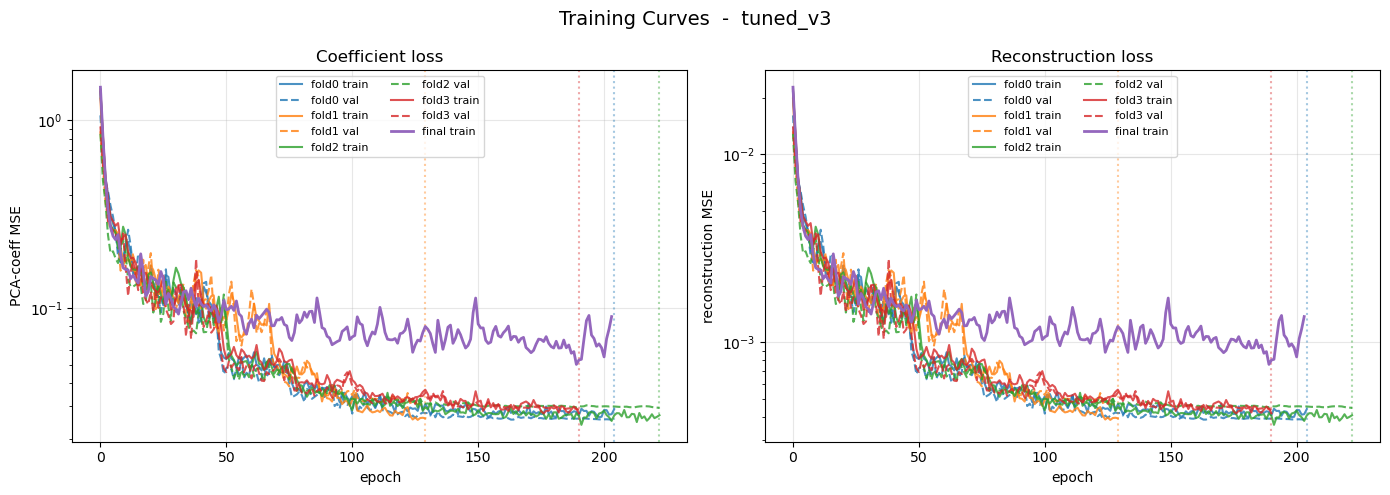

In [41]:
#### PLOT TRAINING CURVES ####
# Train/val loss vs epoch for every CV fold, plus the final-model train curve.
n_folds_plot = len(fold_histories)
colors = plt.cm.tab10(np.arange(n_folds_plot + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

panels = [
    ("train_loss",        "val_loss",        "PCA-coeff MSE",     "Coefficient loss"),
    ("train_loss_recon",  "val_loss_recon",  "reconstruction MSE","Reconstruction loss"),
]
for ax, (tk, vk, ylabel, title) in zip(axes, panels):
    for i, h in enumerate(fold_histories):
        ep = np.arange(len(h[tk]))
        ax.plot(ep, h[tk], color=colors[i], linestyle='-',  alpha=0.8, label=f'fold{i} train')
        ax.plot(ep, h[vk], color=colors[i], linestyle='--', alpha=0.8, label=f'fold{i} val')
        ax.axvline(h["stop_epoch"], color=colors[i], linestyle=':', alpha=0.4)
    ax.plot(
        np.arange(len(final_history[tk])), final_history[tk],
        color=colors[-1], linestyle='-', linewidth=2, label='final train'
    )
    ax.set_yscale('log')
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle(f'Training Curves  -  {NAME}', fontsize=14)
fig.tight_layout()
plt.show()


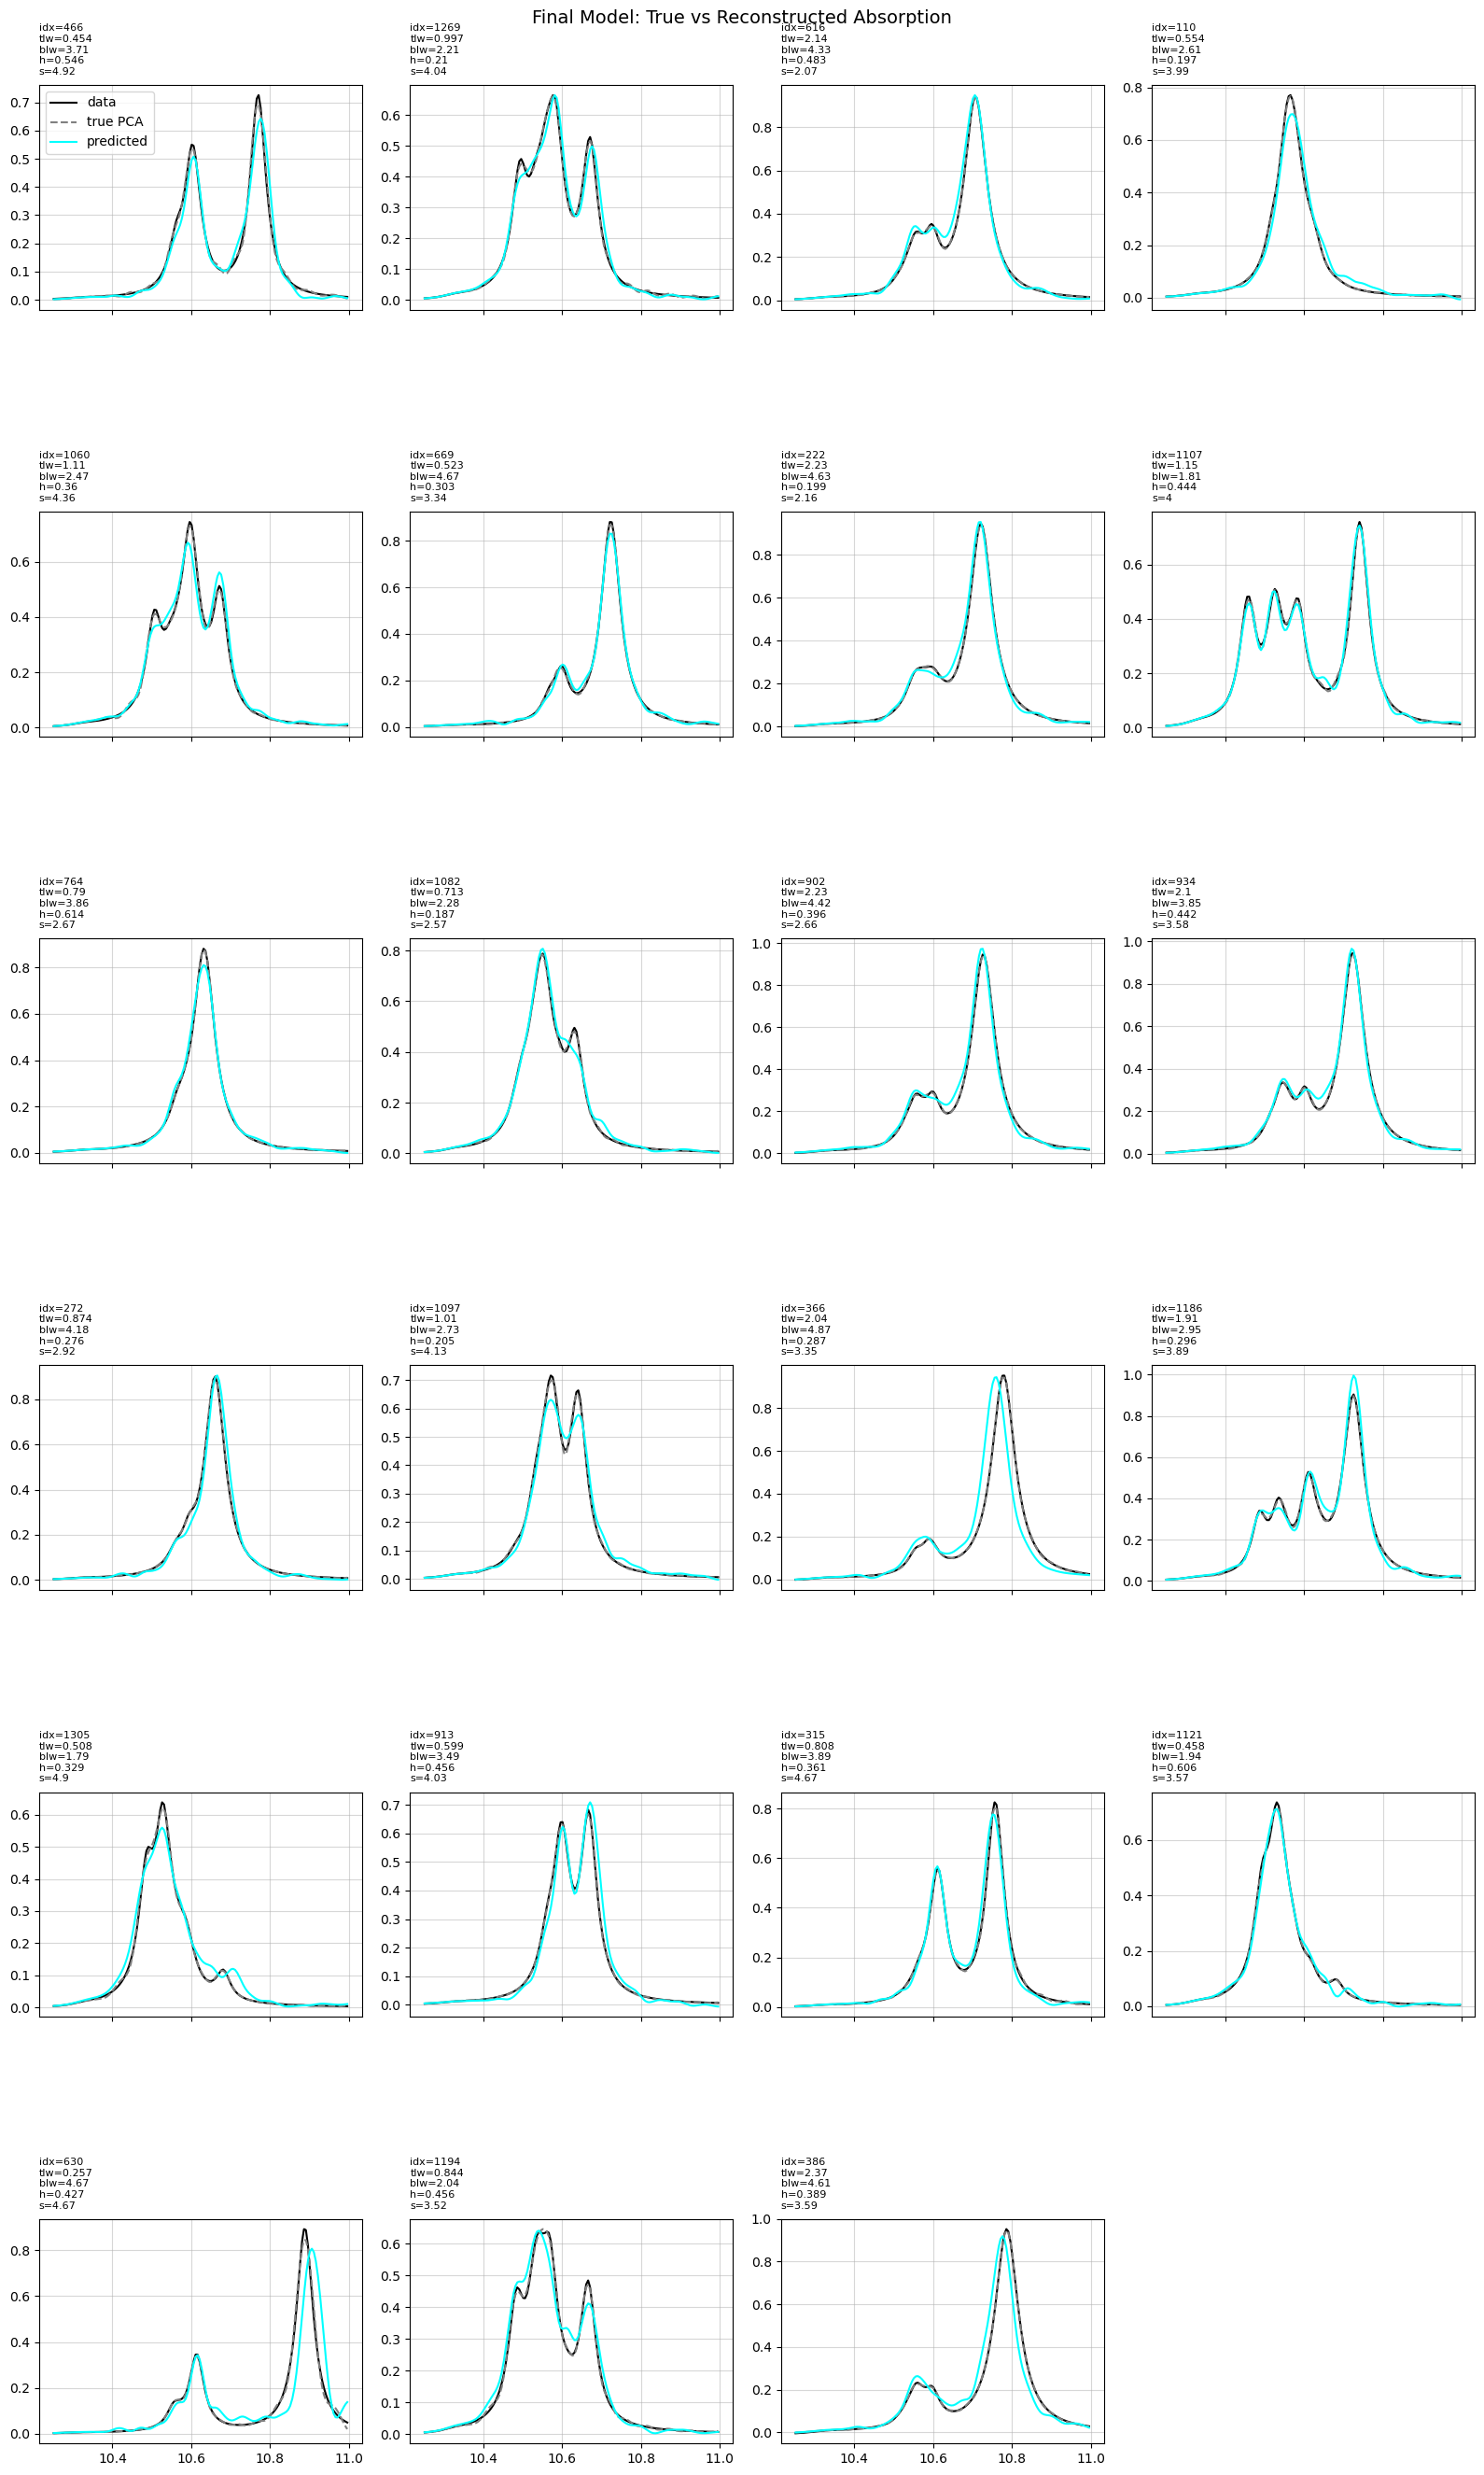

In [42]:
#### PLOT FINAL MODEL RECONSTRUCTIONS ####
plot_idx = np.asarray(test_indices)[::10]

final_model_net.eval()
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    feat_sel = data.feat[plot_idx]
    pred_sel = final_model_net(geom_sel)
    pred_spec_sel = data.reconstruct_spectrum(pred_sel).numpy()
    true_spec_sel = data.reconstruct_spectrum(feat_sel).numpy()
    raw_spec_sel = _raw_abs[plot_idx]

wl_plot = np.asarray(data.wl)
geom_table_sorted = pca_ft['geometry_table'].sort_index()
n_plot = len(plot_idx)
ncols = 4
nrows = (n_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, pred_spec_sel[i], color='cyan', label='predicted')
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)}\n" + "\n".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle("Final Model: True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()


#### <span style="color:cyan">**Training - Final Model (ensemble)**</span>

In [43]:
#### ENSEMBLE (FOLD MODELS) ####
# Load all fold checkpoints and average their coefficient predictions.
# reconstruct_spectrum is linear so averaging coeffs = averaging spectra.
n_folds = loader_config['splits']
fold_models = []
for i in range(n_folds):
    ckpt = torch.load(
        f'{train_config["path"]}/fold{i}/best_pca_reg.pt',
        weights_only=False
    )
    m = PcaMLP(
        MLP_config['k'],
        MLP_config['hidden_dim'],
        MLP_config['n_layers'],
        MLP_config['p'],
        input_dim=MLP_config['input_dim']
    )
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    fold_models.append(m)

# Evaluate ensemble on test set
ens_coeff_sum = 0.0
ens_recon_sum = 0.0
ens_samples = 0
ens_peak_abs_errs = []
ens_peak_loc_errs = []
_mse = torch.nn.MSELoss()

with torch.no_grad():
    for geom, feat in test_loader:
        ensemble_coeffs = torch.stack([m(geom) for m in fold_models]).mean(dim=0)
        pred_spec = data.reconstruct_spectrum(ensemble_coeffs)
        true_spec = data.reconstruct_spectrum(feat)

        batch_n = geom.shape[0]
        ens_coeff_sum += _mse(ensemble_coeffs, feat).item() * batch_n
        ens_recon_sum += ((pred_spec - true_spec) ** 2).mean().item() * batch_n
        ens_samples += batch_n

        pred_peak = pred_spec.max(dim=-1)
        true_peak = true_spec.max(dim=-1)
        ens_peak_abs_errs.append((pred_peak.values - true_peak.values).abs())
        ens_peak_loc_errs.append((wl_tensor[pred_peak.indices] - wl_tensor[true_peak.indices]).abs())

ens_coeff_mse = ens_coeff_sum / max(ens_samples, 1)
ens_recon_mse = ens_recon_sum / max(ens_samples, 1)
ens_peak_mae  = torch.cat(ens_peak_abs_errs).mean().item()
ens_peak_loc  = torch.cat(ens_peak_loc_errs).mean().item()

ensemble_metrics = {
    "test_coeff_mse":      float(ens_coeff_mse),
    "test_recon_mse":      float(ens_recon_mse),
    "test_recon_rmse":     float(math.sqrt(ens_recon_mse)),
    "peak_mae":            float(ens_peak_mae),
    "peak_loc_error_um":   float(ens_peak_loc),
    "n_models":            n_folds,
    "n_test":              int(ens_samples),
}

em_w = max(len(k) for k in ensemble_metrics) + 2
print(f"\n{'='*72}")
print(f"Ensemble ({n_folds} fold models, evaluated once on test)")
print(f"{'='*72}")
for k, v in ensemble_metrics.items():
    fmt = f"{v:>12.6g}" if isinstance(v, float) else f"{v:>12d}"
    print(f"{k:<{em_w}} {fmt}")
print("=" * 72)

# Save ensemble metrics alongside the rest
kfold_results['ensemble'] = ensemble_metrics
with open(f'{DIR}/config/kfold_metrics.json', "w") as f:
    json.dump(kfold_results, f, indent=4, default=_json_default)


Ensemble (4 fold models, evaluated once on test)
test_coeff_mse         0.0277383
test_recon_mse       0.000420023
test_recon_rmse        0.0204945
peak_mae               0.0257425
peak_loc_error_um     0.00866183
n_models                       4
n_test                       223


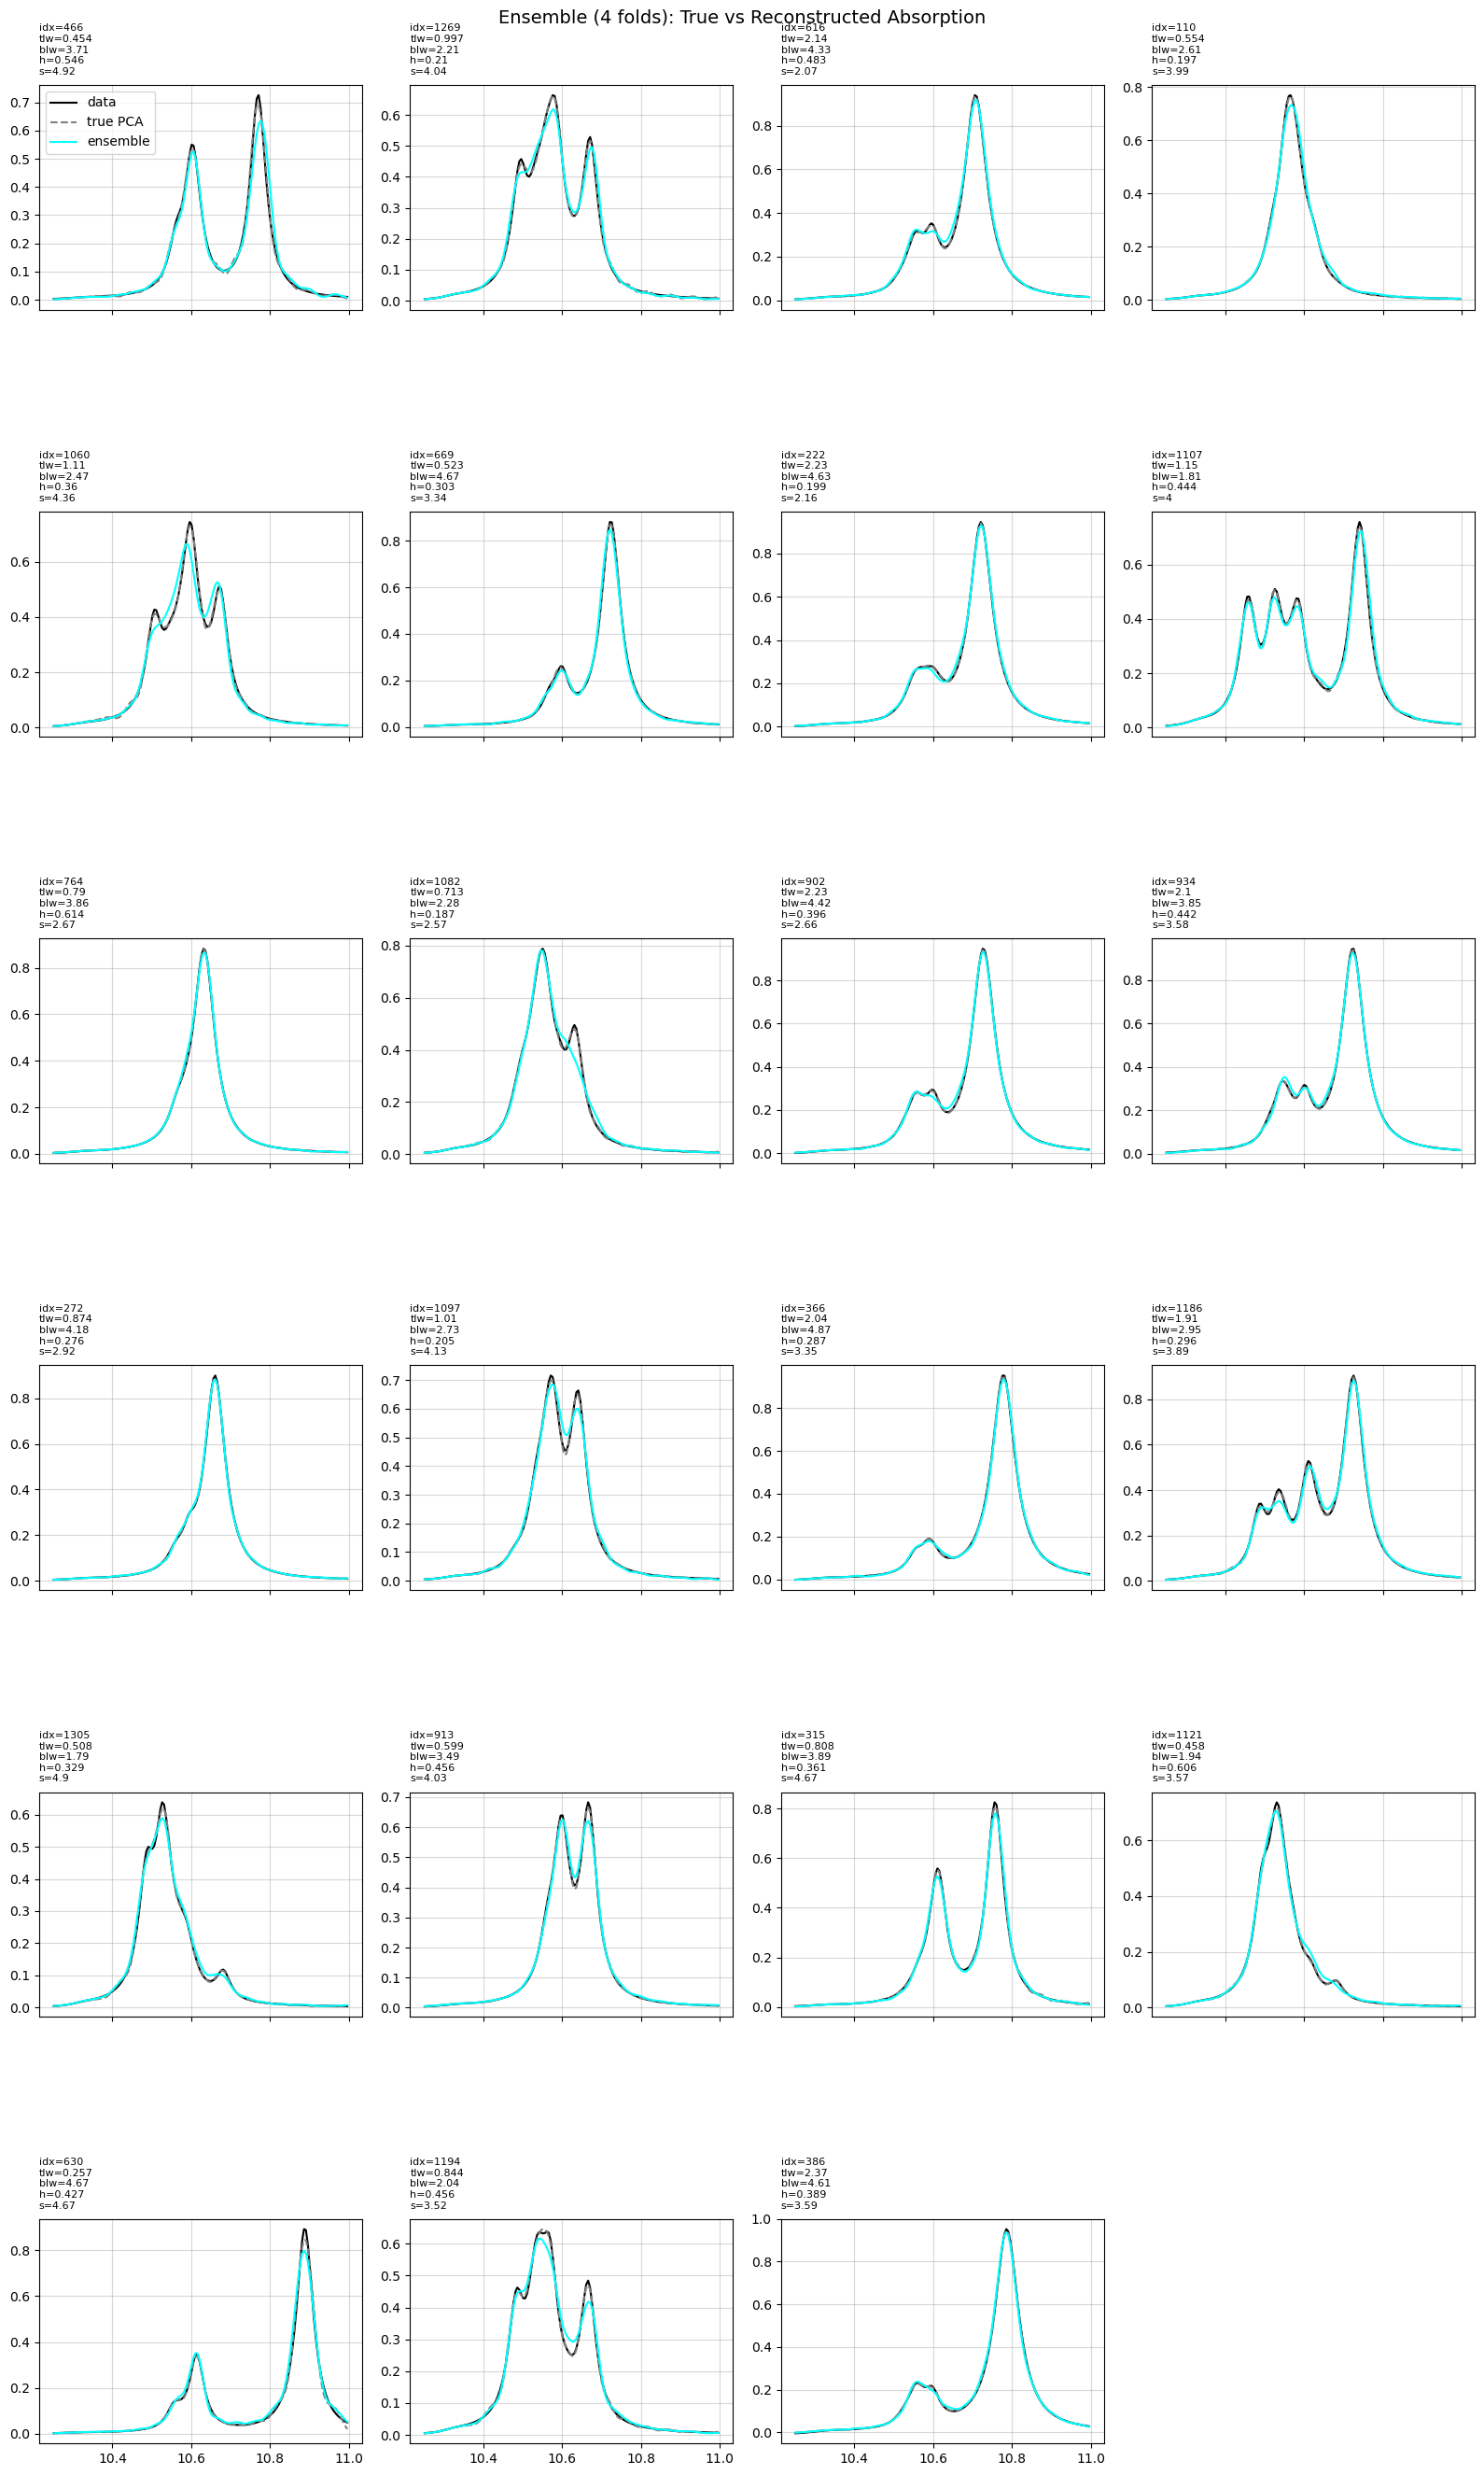

In [44]:
#### PLOT ENSEMBLE RECONSTRUCTIONS ####
with torch.no_grad():
    geom_sel = data.geom[plot_idx]
    feat_sel = data.feat[plot_idx]
    ens_coeffs_sel = torch.stack([m(geom_sel) for m in fold_models]).mean(dim=0)
    ens_spec_sel = data.reconstruct_spectrum(ens_coeffs_sel).numpy()

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows), sharex=True)
axes_flat = np.atleast_1d(axes).flatten()
for i, idx in enumerate(plot_idx):
    ax = axes_flat[i]
    ax.plot(wl_plot, raw_spec_sel[i], color='k', label='data')
    ax.plot(wl_plot, true_spec_sel[i], color='grey', linestyle='--', label='true PCA')
    ax.plot(wl_plot, ens_spec_sel[i], color='cyan', label='ensemble')
    geom_row = geom_table_sorted.iloc[int(idx)]
    title = f"idx={int(idx)}\n" + "\n".join(
        f"{name}={geom_row[name]:.3g}" for name in geom_table_sorted.columns
    )
    ax.set_title(title, fontsize=8, loc='left', pad=8)
    ax.grid(alpha=0.5)
    if i == 0:
        ax.legend()
for j in range(n_plot, len(axes_flat)):
    axes_flat[j].axis('off')
fig.suptitle(f"Ensemble ({n_folds} folds): True vs Reconstructed Absorption", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.95, hspace=0.9)
plt.show()
